# Fine-Tuning PyTorch Models and Foundation Models

This example notebook demonstrates how to train, save, load, and fine-tune PyTorch-based models in Darts. We cover two scenarios:

- [**Regular PyTorch Models**](#1.-Regular-TorchForecastingModel:-Training-and-Fine-Tuning) (e.g., TiDE, N-BEATS, DLinear):
  - **(Pre-)Training** a model from scratch.
  - **Saving and loading** the model.
  - **Fine-tuning** the loaded model (updating weights on new data).

- [**Foundation Models**](#2.-Foundation-Model:-Zero-Shot-Forecasting-and-Fine-Tuning) (e.g., Chronos 2, TimesFM 2.5, TiRex, ...):
  - **Zero-shot inference** for forecasting without any training.
  - **Fine-tuning** the foundation model.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()
%matplotlib inline

In [3]:
import logging
import os
import warnings

import matplotlib.pyplot as plt

from darts import set_option
from darts.datasets import AirPassengersDataset, AusBeerDataset
from darts.metrics import mae
from darts.models import Chronos2Model, TiDEModel
from darts.utils.callbacks import TFMProgressBar

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)
set_option("plotting.use_darts_style", True)

## Data Preparation

For demonstration, we'll just load two short time series: The Air Passengers and Australian Beer Production datasets.
We will pre-train a model only on the Air Passengers series and then fine-tune it on the Beer Production dataset. 
We also create training, evaluation and test sets for illustration.

<div class="alert alert-success" role="alert">
    **Note**: Our two datasets have different frequencies (monthly and quarterly), but our torch models can handle this out of the box!
</div>

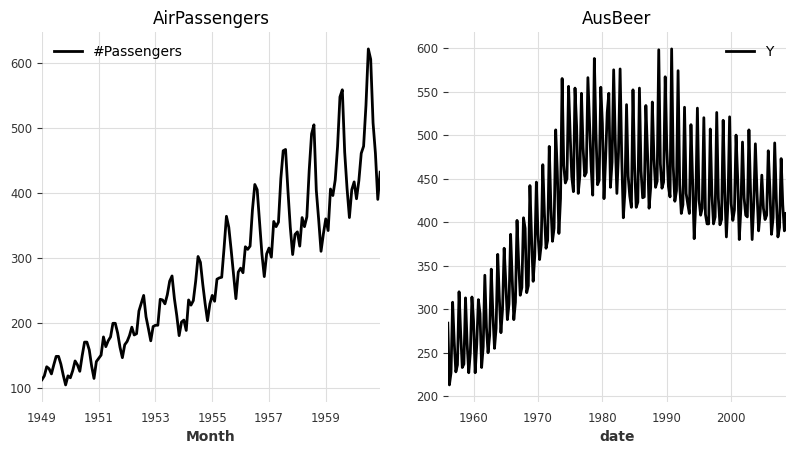

In [4]:
input_chunk_length = 24  # model input window
output_chunk_length = 12  # model output_window

# load air passengers series
series_air = AirPassengersDataset().load().astype("float32")
series_beer = AusBeerDataset().load().astype("float32")

# plot everything
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(9.6, 4.8))
series_air.plot(ax=ax1, title="AirPassengers")
series_beer.plot(ax=ax2, title="AusBeer")

# extract training and validation sets
train_air = series_air[: -2 * output_chunk_length]
val_air = series_air[
    -(2 * output_chunk_length + input_chunk_length) : -output_chunk_length
]

train_beer = series_beer[: -2 * output_chunk_length]
val_beer = series_beer[
    -(2 * output_chunk_length + input_chunk_length) : -output_chunk_length
]

## 1. Regular TorchForecastingModel: Training and Fine Tuning

We start with a regular `TorchForecastingModel` (non-foundation model); `TiDEModel` in this case.


### 1.1. Training

First, we train the model from scratch only on the air passengers series. By default, `enable_finetuning=None`, which implies standard training for regular models (all weights are trainable).

<div class="alert alert-success" role="alert">
    **Note**: For demonstration purposes, we only show training and predicting on single univariate `TimeSeries` (one series with one column). The process is identical for multiple (a list / sequence) uni- or multivariate series.
</div>

Training: 0it [00:00, ?it/s]

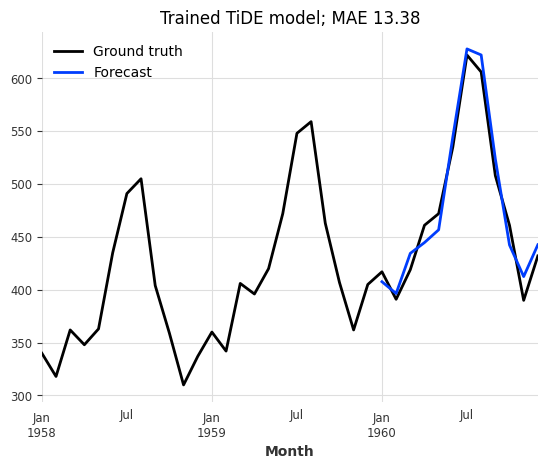

In [5]:
# setup common torch model parameters
model_params = dict(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    use_reversible_instance_norm={"affine": False},
    random_state=42,
    save_checkpoints=True,  # store checkpoints during training to retrieve the best model
    model_name="tide",
    force_reset=True,  # overwrite previous model artifacts,
    pl_trainer_kwargs={
        "callbacks": [TFMProgressBar(enable_train_bar_only=True)]
    },  # reduce the verbosity
)

# regular training (default enable_finetuning=None)
model_pretrained = TiDEModel(**model_params)

# fit
model_pretrained.fit(
    series=train_air,
    val_series=val_air,  # use a validation set to monitor model performance
    load_best=True,  # load the best model checkpoint at the end of training
    epochs=50,  # train for 50 epochs
)

# predict after the end of the validation series
pred_air = model_pretrained.predict(n=output_chunk_length, series=val_air)

# save the pre-trained model
model_path = os.path.join("darts_logs", "model.pt")
model_pretrained.save(model_path)

# plot
series_air[-3 * output_chunk_length :].plot(label="Ground truth")
pred_air.plot(
    label="Forecast",
    title=f"Trained TiDE model; MAE {mae(series_air, pred_air):.2f}",
);

Great, this looks like a very good forecast! Now let's see how the model performs on the beer production series.

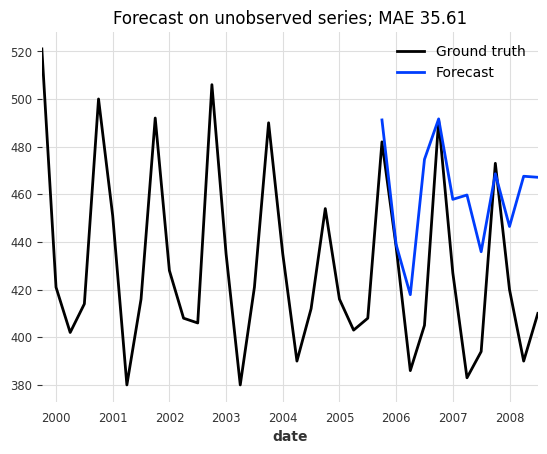

In [6]:
# predict
pred_beer = model_pretrained.predict(n=output_chunk_length, series=val_beer)

# plot
series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
pred_beer.plot(
    label="Forecast",
    title=f"Forecast on unobserved series; MAE {mae(series_beer, pred_beer):.2f}",
);

That doesn't look very good. It seems like our model does not generalize to our new beer dataset.

### 1.2. Fine-Tuning

Imagine the model above was a large **pre-trained model** and **full re-training** would take hours. Instead, we can also **fine-tune** parts of the model on this new dataset to, potentially, improve performance. For this we will:

1. Create a new `model` instance for fine-tuning with the same architectural hyperparameters, and enable fine-tuning with the `enable_finetuning` parameter. We restrict fine-tuning to only the "decoder" parameters.
2. Load the weights of the pre-trained model with `model.load_weights()`.
3. Fine-tune the model with `model.fit()`.

The `enable_finetuning` model creation parameter controls how the model is updated during `fit()`. Possible values are:
*   `None` (Default): **Regular training** for regular PyTorch models (TiDE, ...) and **zero-shot inference mode** for foundation models (Chronos-2, ...).
*   `False`: **Zero-shot inference mode**. The model weights are frozen.
*   `True`: **Full fine-tuning / training**. All weights are trainable.
*   `{"unfreeze": ["*string.pattern.to.match*", ...]}`: **Partial fine-tuning (Unfreeze)**. None of the parameters are trainable *except* the specified unfrozen ones
*   `{"freeze": ["*string.pattern.to.match*", ...]}`: **Partial fine-tuning (Freeze)**. All parameters are trainable *except* the specified frozen ones.

<div class="alert alert-success" role="alert">
    **Note**: You can inspect the model's parameters by printing the architecture with `print(model.model)` or getting the named parameters directly with `model.model.named_parameters()`
</div>

Training: 0it [00:00, ?it/s]

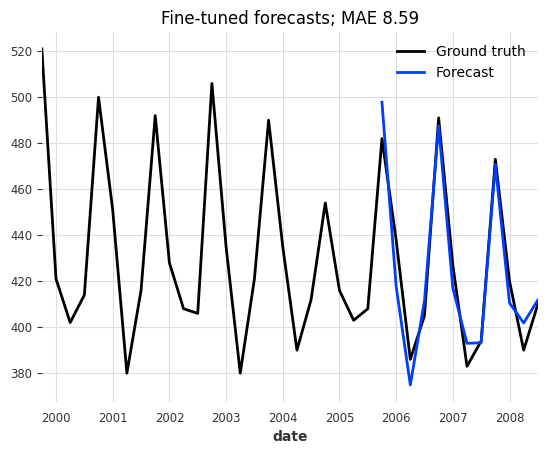

In [7]:
# create a new model instance for fine-tuning with the same hyperparameters but different training setup
model_finetune = TiDEModel(
    enable_finetuning={"unfreeze": ["*decoder*"]},  # only update the decoder
    optimizer_kwargs={
        "lr": 1e-3
    },  # control the optimizer, learning rate scheduler, ...
    **model_params,
)

# load the pre-trained weights
model_finetune.load_weights(model_path)

# fine-tune only for 10 epochs
model_finetune.fit(train_beer, val_series=val_beer, load_best=True, epochs=10)

# hint: you can save the fine-tuned model with: `model_finetune.save()`

# predict after the end of the validation series
pred_beer = model_finetune.predict(n=output_chunk_length, series=val_beer)

# plot
series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
pred_beer.plot(
    label="Forecast",
    title=f"Fine-tuned forecasts; MAE {mae(series_beer, pred_beer):.2f}",
);

That looks much better! This demonstrates that **fine-tuning can significantly improve model performance** on new datasets, without having to re-train the entire model from scratch.

## 2. Foundation Model: Zero Shot Forecasting and Fine Tuning

Now we move to foundation models (e.g. Chronos-2, TimesFM 2.5, ...). These models are pre-trained on large datasets and can be used for **zero-shot forecasting** (without training). However, **fine-tuning** them on your specific data **often improves performance**.

### 2.1. Zero-Shot Inference
By default, our foundation models use `enable_finetuning=False` (zero-shot inference mode). Let's see how the model behaves on Australian Beer Production dataset without any training / fine-tuning.

<div class="alert alert-success" role="alert">
    **Note**:
    <ol>
        <li>We only load the small version of Chronos-2 to speed things up for demonstration purposes. You can always use the large model with `hub_model_name="amazon/chronos-2"`.
        <li>Foundation models were trained on much larger input- and output chunk lengths (windows) than in our example. Increasing the window sizes (especially the input window) can significantly improve performance.
    </ol>
</div>

Predicting: |                                             | 0/? [00:00<?, ?it/s]

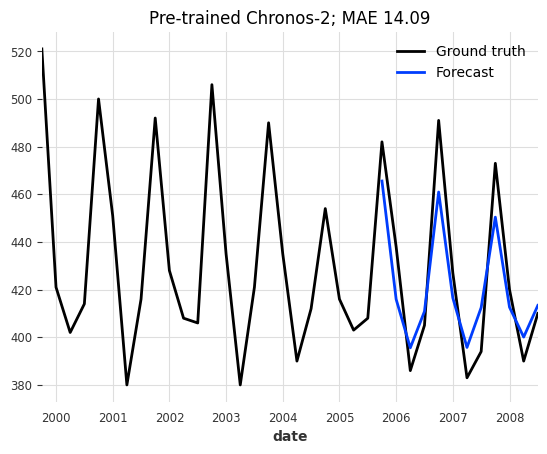

In [8]:
model_params = dict(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    random_state=42,
    hub_model_name="autogluon/chronos-2-small",  # small chronos version
)
model = Chronos2Model(**model_params)

# by default for foundation models, `fit()` will only load the model but does not perform fine-tuning / training
model.fit(series=train_beer)

# predict
pred_beer = model.predict(n=output_chunk_length, series=val_beer)

# plot
series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
pred_beer.plot(
    label="Forecast",
    title=f"Pre-trained Chronos-2; MAE {mae(series_beer, pred_beer):.2f}",
);

For a zero-shot forecast, the results are already quite decent! 

### 2.2. Fine-Tuning

And how does it look after fine-tuning the output layers of the model on the dataset?

<details>

<summary><strong>TiRex: Fine-tunable layers</strong></summary>

TiRex uses sLSTM blocks with bfloat16 recurrence. Backpropagating through the time-loop in the **first 8 blocks** produces NaN gradients on the first backward pass — this is a structural precision constraint, not a learning rate issue. The safe fine-tunable region is:

| Layer group                           | Trainable params | Gradient-safe?  |
|---------------------------------------|------------------|-----------------|
| `output_patch_embedding` + `out_norm` | ~1.8M            | ✓               |
| Last 4 blocks (8–11) + output head    | ~12.6M           | ✓               |
| First 8 blocks or full model          | all              | ✗ NaN gradients |

<div class="alert alert-warning" role="alert">
  **Backend requirement**: Fine-tuning requires `tirex_kwargs={"backend": "torch"}`.
</div>

</details>

Training: 0it [00:00, ?it/s]

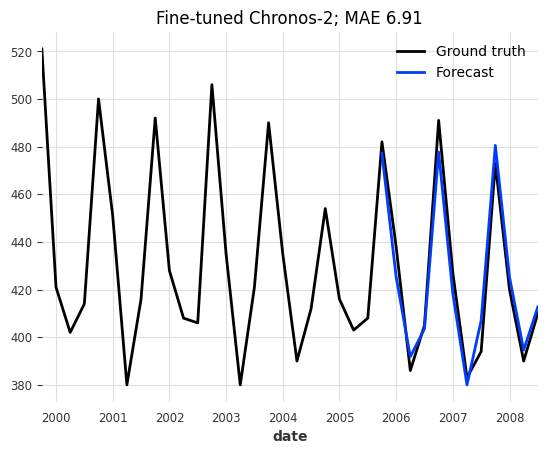

In [9]:
# setup fine-tuning; only tune the layers matching "output_patch_embedding"
model_finetune = Chronos2Model(
    enable_finetuning={"unfreeze": ["output_patch_embedding*"]},
    save_checkpoints=True,
    model_name="chronos",
    force_reset=True,
    optimizer_kwargs={"lr": 1e-3},
    pl_trainer_kwargs=dict(
        check_val_every_n_epoch=5,
        gradient_clip_val=1,
        callbacks=[TFMProgressBar(enable_train_bar_only=True)],
    ),
    **model_params,
)

# fine-tune for 15 epochs
model_finetune.fit(
    series=train_beer,
    val_series=val_beer,
    load_best=True,
    epochs=15,
)

# predict
pred_beer = model_finetune.predict(n=output_chunk_length, series=val_beer)

# hint: you can store the fine-tuned model with `model_finetune.save()`

# plot
series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
pred_beer.plot(
    label="Forecast",
    title=f"Fine-tuned Chronos-2; MAE {mae(series_beer, pred_beer):.2f}",
);

Again, the results are much better than before fine-tuning!

## Conclusion & Summary

While the results on these small "toy" datasets (Air Passengers, Australian Beer Production) may vary depending on the random seed and hyperparameters, they demonstrate the flexibility and effectiveness of fine-tuning.

**Pre-trained models** and their capability to generate **Zero-Shot** forecasts can be quite powerful in real-world scenarios with:
- **Large datasets** where training from scratch would be too complex and / or costly
- **Small datasets** where not enough data is available to robustly train a model.

**Fine-tuning** allows updating a pre-trained model on new data, potentially improving the model performace while saving training time compared to retraining from scratch.

- **Full Fine-tuning**: Offers the most flexibility but is computationally expensive and prone to "catastrophic forgetting".
- **Partial Fine-tuning**: Provides a good middle ground by updating only the most relevant layers (like the output head).

For demonstration purposes, we only showed training and predicting on single univariate series (one series with one column). The process is identical for **multiple (a list / sequence) uni- or multivariate series**.